# fly.ai quickstart: poke a real fly brain

This notebook loads the complete central nervous system of an adult male fruit fly
(166,700 neurons and 25.6 million connections from the [MaleCNS v1.0 connectome](https://male-cns.janelia.org)),
stimulates a handful of its visual neurons, and watches what comes out of the brain.

No training is involved. Everything you see comes from the wiring.

**Before running:** build the brain once from the repository root with `python build_brain.py`
(downloads ~1.1 GB). For the plots you also need `pip install matplotlib`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd().parent))  # the fly.ai core lives at the repository root
from fly_brain import FlyBrain

brain = FlyBrain(device="auto")  # uses an NVIDIA GPU if CuPy is installed, else the CPU
print(f"{brain.n:,} neurons, {len(brain.indices):,} connections, running on {brain.device}")

166,700 neurons, 25,582,938 connections, running on cuda


## What is in there

Every neuron has a cell type, a side of the body and a superclass. The *descending neurons*
are the brain's output cables: the commands it sends down to the body.

In [2]:
classes, counts = np.unique(brain.superclass, return_counts=True)
for c, k in sorted(zip(classes, counts), key=lambda x: -x[1])[:12]:
    print(f"{k:7,}  {c}")

 89,403  ol_intrinsic
 32,164  cb_intrinsic
 13,161  vnc_intrinsic
  9,201  visual_projection
  6,370  vnc_sensory
  6,098  ol_sensory
  4,868  cb_sensory
  1,846  ascending_neuron
  1,314  descending_neuron
    708  vnc_motor
    563  visual_centrifugal
    537  sensory_ascending


## Experiment 1: something looming on the left

In a real fly, **LC4** and **LPLC2** neurons detect a looming object (a predator, a fly swatter)
and drive the **giant fiber, DNp01**, which fires the escape jump.

We stimulate only the *left* LC4 and LPLC2 neurons between 1 and 2 seconds and record the left
and right giant fibers.

stimulating 165 looming-detector neurons on the left


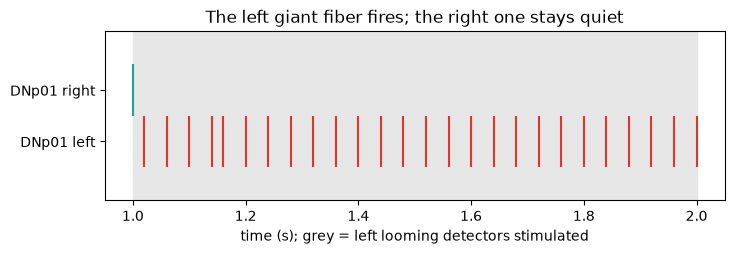

In [3]:
loom_left = brain.cells(["LC4", "LPLC2"], side="L")
giant_fiber = {s: brain.cells(["DNp01"], side=s) for s in "LR"}
print(f"stimulating {len(loom_left)} looming-detector neurons on the left")

def record(stim_cells, strength=0.8, seconds=3.0, on=(1.0, 2.0), seed=0, watch=giant_fiber):
    """Run the brain, stimulating `stim_cells` during `on`. Returns spike times per watched group
    and each neuron's spike count while the stimulus was on."""
    brain.reset(seed)
    spikes = {k: [] for k in watch}
    counts = np.zeros(brain.n, np.int32)
    for step in range(int(seconds / brain.dt)):
        t = step * brain.dt
        if on[0] <= t < on[1]:
            brain.stimulate(stim_cells, strength)
        fired = brain.step()
        if on[0] <= t < on[1]:
            counts[fired] += 1
        for k, idx in watch.items():
            spikes[k] += [t] * int(np.isin(idx, fired).sum())
    return spikes, counts

spikes, counts = record(loom_left)
fig, ax = plt.subplots(figsize=(8, 2.2))
for row, (side, times) in enumerate(spikes.items()):
    ax.eventplot([times], lineoffsets=row, colors="#e0342c" if side == "L" else "#2a9d8f")
ax.axvspan(1, 2, color="0.9", zorder=0)
ax.set_yticks([0, 1], ["DNp01 left", "DNp01 right"])
ax.set_xlabel("time (s); grey = left looming detectors stimulated")
ax.set_title("The left giant fiber fires; the right one stays quiet")
plt.show()

The escape pathway is there in the wiring, and it is **side-specific**. We never told the
model which side is which: the left detectors happen to connect to the left giant fiber.

## Where the activity goes

Every dot is a neuron at its measured position in the fly (brain at the top, nerve cord below).
The network is never silent: background noise makes neurons fire everywhere. So we run the same
second again with the same noise but no stimulus, and light up (red) only the neurons that fired
at least twice more when the left looming detectors were on.

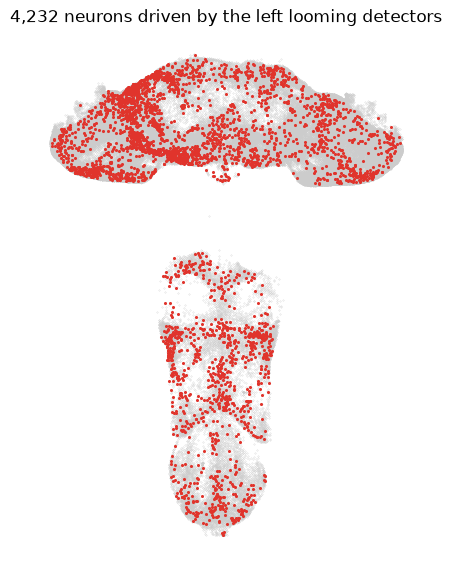

In [4]:
_, rest_counts = record(np.array([], int))
active = counts - rest_counts >= 2
ok = ~np.isnan(brain.positions).any(axis=1)
xy = brain.positions[:, [0, 2]]
if np.nanmean(xy[brain.side == "R", 0]) < np.nanmean(xy[brain.side == "L", 0]):
    xy = xy * [-1, 1]  # draw the fly's right on the viewer's right
fig, ax = plt.subplots(figsize=(5, 8))
ax.scatter(*xy[ok & ~active].T, s=0.05, c="0.8", rasterized=True)
ax.scatter(*xy[ok & active].T, s=1.5, c="#e0342c", rasterized=True)
ax.invert_yaxis()
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(f"{active.sum():,} neurons driven by the left looming detectors")
plt.show()

## Experiment 2: the chase pathway

Males chase females during courtship. **LC10a** neurons track a moving target, and the
**DNa02** neurons steer the fly while walking. If we stimulate the left LC10a neurons, the
left DNa02 should fire more than the right one. We average over a few noise seeds, because the
effect is smaller than the escape response.

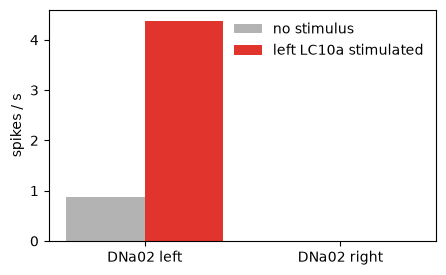

rest : {'L': 0.9, 'R': 0.0}
chase: {'L': 4.4, 'R': 0.0}


In [5]:
chase_left = brain.cells(["LC10a"], side="L")
steer = {s: brain.cells(["DNa02"], side=s) for s in "LR"}

def rates(stim, seeds=range(4)):
    out = {s: [] for s in "LR"}
    for seed in seeds:
        spikes, _ = record(stim, seconds=2.5, on=(0.5, 2.5), seed=seed, watch=steer)
        for s in "LR":
            out[s].append(len([t for t in spikes[s] if t >= 0.5]) / 2.0)
    return {s: float(np.mean(v)) for s, v in out.items()}

rest, chase = rates(np.array([], int)), rates(chase_left)
fig, ax = plt.subplots(figsize=(5, 3))
x = np.arange(2)
ax.bar(x - 0.2, [rest["L"], rest["R"]], 0.4, label="no stimulus", color="0.7")
ax.bar(x + 0.2, [chase["L"], chase["R"]], 0.4, label="left LC10a stimulated", color="#e0342c")
ax.set_xticks(x, ["DNa02 left", "DNa02 right"])
ax.set_ylabel("spikes / s")
ax.legend(frameon=False)
plt.show()
print("rest :", {k: round(v, 1) for k, v in rest.items()})
print("chase:", {k: round(v, 1) for k, v in chase.items()})

## Your turn

* `brain.cells(["SomeType"], side="L")` finds neurons by cell type. Browse the types in
  `np.unique(brain.cell_type)` or look them up on [neuPrint](https://neuprint.janelia.org)
  (dataset `male-cns:v1.0`).
* `brain.stimulate(indices, amount)` injects voltage, and `brain.step()` advances 20 ms and
  returns which neurons fired.
* `brain.reset(seed)` silences the network and restarts the noise.

To see the same brain play a fighting game, go to [`sshfighter/`](../sshfighter/).